# 06 — Claim Occurrence Models

## Projet : AI Business Advisor V2

### Objectif

L'objectif est de comparer plusieurs modèles supervisés pour prédire
la probabilité qu'une police présente au moins un sinistre.

La cible est :

- `0` : aucun sinistre ;
- `1` : au moins un sinistre.

Le problème est fortement déséquilibré, avec environ 5 % de positifs.

Les modèles seront comparés uniquement sur le jeu de développement
à l'aide des mêmes folds de validation croisée.

Le jeu de test final de 20 % reste totalement inaccessible pendant :

- la comparaison des modèles ;
- le tuning ;
- la sélection des features ;
- le choix du seuil.

La métrique principale est PR-AUC (Average Precision).

In [1]:
import pandas as pd
import numpy as np

import json
import time

import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    confusion_matrix,
    classification_report
)

from sklearn.calibration import calibration_curve


RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
try:
    from xgboost import XGBClassifier

    XGBOOST_AVAILABLE = True

    print("XGBoost disponible.")

except ImportError:

    XGBOOST_AVAILABLE = False

    print("XGBoost n'est pas encore installé.")

XGBoost disponible.


## Stratégie de comparaison

Les modèles représentent différentes familles :

### DummyClassifier

Baseline minimale.

Il permet de vérifier que les vrais modèles apportent réellement
de l'information au-delà de la distribution de la cible.

### Logistic Regression

Baseline supervisée linéaire, simple et interprétable.

### Logistic Regression avec class_weight

Permet d'étudier l'impact du déséquilibre de classes.

### Random Forest

Modèle non linéaire capable d'apprendre des interactions
et des relations complexes.

### XGBoost

Gradient boosting sur arbres, permettant de représenter des relations
non linéaires et interactions complexes.

Aucun de ces modèles n'est considéré comme final à ce stade.

In [3]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:

    if path.exists():

        PROCESSED_DIR = path
        break

if PROCESSED_DIR is None:

    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = PROCESSED_DIR.parent

METADATA_DIR = DATA_DIR / "metadata"

PROJECT_DS_DIR = DATA_DIR.parent

REPORT_DIR = (
    PROJECT_DS_DIR
    / "reports"
    / "models"
    / "claim_occurrence"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed :", PROCESSED_DIR.resolve())
print("Metadata  :", METADATA_DIR.resolve())
print("Reports   :", REPORT_DIR.resolve())

Processed : C:\Users\user\ai-business-advisor-v2\data-science\data\processed
Metadata  : C:\Users\user\ai-business-advisor-v2\data-science\data\metadata
Reports   : C:\Users\user\ai-business-advisor-v2\data-science\reports\models\claim_occurrence


In [4]:
occurrence = pd.read_csv(
    PROCESSED_DIR
    / "claim_occurrence_modeling_base.csv"
)

print(
    occurrence.shape
)

occurrence.head()

(676789, 12)


,IDpol,Exposure,VehPower,VehAge,DrivAge,BonusMalus,log_density,Area,VehBrand,VehGas,Region,has_claim
0,1,0.10,5,0,55,50,7.104965,D,B12,Regular,R82,1
1,3,0.77,5,0,55,50,7.104965,D,B12,Regular,R82,1
2,5,0.75,6,2,52,50,4.007333,B,B12,Diesel,R22,1
3,10,0.09,7,0,46,50,4.343805,B,B12,Diesel,R72,1
4,11,0.84,7,0,46,50,4.343805,B,B12,Diesel,R72,1


In [5]:
split_df = pd.read_csv(
    METADATA_DIR
    / "freMTPL2_split.csv"
)

split_df.head()

split_df["split"].value_counts()

split
development    541431
test           135358
Name: count, dtype: int64

In [6]:
occurrence = occurrence.merge(
    split_df,
    on="IDpol",
    how="left",
    validate="one_to_one"
)



In [7]:
occurrence["split"].value_counts(
    dropna=False
)

split
development    541431
test           135358
Name: count, dtype: int64

In [8]:
occurrence_dev = (
    occurrence[
        occurrence["split"]
        == "development"
    ]
    .copy()
)

occurrence_test = (
    occurrence[
        occurrence["split"]
        == "test"
    ]
    .copy()
)

print(
    "DEV :",
    occurrence_dev.shape
)

print(
    "TEST :",
    occurrence_test.shape
)

DEV : (541431, 13)
TEST : (135358, 13)


In [9]:
assert set(
    occurrence_dev["IDpol"]
).isdisjoint(
    set(
        occurrence_test["IDpol"]
    )
)

print(
    "Aucun chevauchement DEV / TEST : OK"
)

Aucun chevauchement DEV / TEST : OK


## Politique du Test Set

Le dataframe `occurrence_test` est chargé uniquement afin de vérifier
l'intégrité de la partition.

À partir de maintenant, il ne sera utilisé dans aucune comparaison
de modèles de ce notebook.

Tous les résultats ci-dessous sont calculés uniquement sur
`occurrence_dev`.

In [10]:
with open(
    METADATA_DIR
    / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)

    config = (
    feature_manifest[
        "claim_occurrence"
    ]
)
    config

In [11]:
numeric_features = (
    config[
        "numeric_features"
    ]
)

categorical_features = (
    config[
        "categorical_features"
    ]
)

features = (
    numeric_features
    +
    categorical_features
)

target = config["target"]


print(
    "Numeric :",
    numeric_features
)

print()

print(
    "Categorical :",
    categorical_features
)

print()

print(
    "Target :",
    target
)

Numeric : ['Exposure', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'log_density']

Categorical : ['Area', 'VehBrand', 'VehGas', 'Region']

Target : has_claim


In [12]:
X_dev = (
    occurrence_dev[
        features
    ]
    .copy()
)

y_dev = (
    occurrence_dev[
        target
    ]
    .copy()
)

print(
    X_dev.shape
)

print(
    y_dev.shape
)

(541431, 10)
(541431,)


In [13]:
assert "ClaimNb" not in X_dev.columns

assert "has_claim" not in X_dev.columns

assert "IDpol" not in X_dev.columns

print(
    "Leakage checks : OK"
)

Leakage checks : OK


In [14]:
class_distribution = (
    y_dev
    .value_counts()
    .sort_index()
)

class_distribution

has_claim
0    514224
1     27207
Name: count, dtype: int64

In [15]:
class_distribution_pct = (
    y_dev
    .value_counts(
        normalize=True
    )
    .sort_index()
    * 100
)

class_distribution_pct

has_claim
0    94.974983
1     5.025017
Name: proportion, dtype: float64

In [16]:
positive_rate = (
    y_dev.mean()
)

print(
    f"Prévalence classe positive : {positive_rate:.4%}"
)

Prévalence classe positive : 5.0250%


In [17]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [18]:
fold_summary = []

for fold_id, (
    train_idx,
    val_idx
) in enumerate(
    cv.split(
        X_dev,
        y_dev
    ),
    start=1
):

    y_train_fold = (
        y_dev.iloc[
            train_idx
        ]
    )

    y_val_fold = (
        y_dev.iloc[
            val_idx
        ]
    )

    fold_summary.append({
        "fold":
            fold_id,

        "train_size":
            len(train_idx),

        "validation_size":
            len(val_idx),

        "train_positive_rate":
            y_train_fold.mean(),

        "validation_positive_rate":
            y_val_fold.mean()
    })

In [19]:
pd.DataFrame(
    fold_summary
)

,fold,train_size,validation_size,train_positive_rate,validation_positive_rate
0,1,433144,108287,0.050249,0.050255
1,2,433145,108286,0.050249,0.050256
2,3,433145,108286,0.050251,0.050247
3,4,433145,108286,0.050251,0.050247
4,5,433145,108286,0.050251,0.050247


In [20]:
scoring = {

    "pr_auc":
        "average_precision",

    "roc_auc":
        "roc_auc",

    "precision":
        make_scorer(
            precision_score,
            zero_division=0
        ),

    "recall":
        make_scorer(
            recall_score,
            zero_division=0
        ),

    "f1":
        make_scorer(
            f1_score,
            zero_division=0
        ),

    "brier":
        "neg_brier_score"
}

In [21]:
numeric_linear_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [22]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_linear_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [23]:
numeric_tree_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_tree_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [24]:
dummy_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="prior"
            )
        )
    ]
)

In [25]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [26]:
logistic_balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [27]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [28]:
XGBOOST_AVAILABLE

True

In [29]:
n_negative = (
    (y_dev == 0)
    .sum()
)

n_positive = (
    (y_dev == 1)
    .sum()
)

class_ratio = (
    n_negative
    /
    n_positive
)

print(
    "Negative / Positive :",
    class_ratio
)

Negative / Positive : 18.900430036387693


In [30]:
if XGBOOST_AVAILABLE:

    xgb_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",

                    n_estimators=300,
                    learning_rate=0.05,
                    max_depth=6,

                    subsample=0.8,
                    colsample_bytree=0.8,

                    scale_pos_weight=class_ratio,

                    tree_method="hist",

                    random_state=RANDOM_STATE,

                    n_jobs=-1
                )
            )
        ]
    )

### XGBoost et le déséquilibre

`scale_pos_weight` augmente le poids de la classe positive.

Une valeur initiale courante est :

`nombre négatifs / nombre positifs`.

Cette valeur constitue ici une configuration de départ.

Elle ne sera considérée comme optimale qu'après validation expérimentale.

In [31]:
models = {

    "dummy_prior":
        dummy_pipeline,

    "logistic":
        logistic_pipeline,

    "logistic_balanced":
        logistic_balanced_pipeline,

    "random_forest":
        random_forest_pipeline
}

In [32]:
if XGBOOST_AVAILABLE:

    models[
        "xgboost"
    ] = xgb_pipeline

    models.keys()

In [33]:
def evaluate_model_cv(
    name,
    pipeline,
    X,
    y,
    cv,
    scoring
):

    print(
        "=" * 70
    )

    print(
        f"Modèle : {name}"
    )

    print(
        "=" * 70
    )

    start = time.perf_counter()

    cv_results = cross_validate(
        estimator=pipeline,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,

        # volontairement 1 pour éviter
        # plusieurs gros folds en mémoire simultanément
        n_jobs=1,

        error_score="raise"
    )

    elapsed = (
        time.perf_counter()
        -
        start
    )

    result = {

        "model":
            name,

        "pr_auc_mean":
            cv_results[
                "test_pr_auc"
            ].mean(),

        "pr_auc_std":
            cv_results[
                "test_pr_auc"
            ].std(),

        "roc_auc_mean":
            cv_results[
                "test_roc_auc"
            ].mean(),

        "roc_auc_std":
            cv_results[
                "test_roc_auc"
            ].std(),

        "precision_mean":
            cv_results[
                "test_precision"
            ].mean(),

        "recall_mean":
            cv_results[
                "test_recall"
            ].mean(),

        "f1_mean":
            cv_results[
                "test_f1"
            ].mean(),

        "brier_mean":
            -cv_results[
                "test_brier"
            ].mean(),

        "fit_time_mean":
            cv_results[
                "fit_time"
            ].mean(),

        "total_time_seconds":
            elapsed
    }

    return result

In [34]:
dummy_result = evaluate_model_cv(
    name="dummy_prior",
    pipeline=dummy_pipeline,
    X=X_dev,
    y=y_dev,
    cv=cv,
    scoring=scoring
)

dummy_result

Modèle : dummy_prior


{'model': 'dummy_prior',
 'pr_auc_mean': np.float64(0.05025017037227347),
 'pr_auc_std': np.float64(4.412872332229626e-06),
 'roc_auc_mean': np.float64(0.5),
 'roc_auc_std': np.float64(0.0),
 'precision_mean': np.float64(0.0),
 'recall_mean': np.float64(0.0),
 'f1_mean': np.float64(0.0),
 'brier_mean': np.float64(0.04772509076078477),
 'fit_time_mean': np.float64(2.9803133487701414),
 'total_time_seconds': 20.521207700003288}

In [35]:
logistic_result = evaluate_model_cv(
    name="logistic",
    pipeline=logistic_pipeline,
    X=X_dev,
    y=y_dev,
    cv=cv,
    scoring=scoring
)

logistic_result

Modèle : logistic


{'model': 'logistic',
 'pr_auc_mean': np.float64(0.09258793036548195),
 'pr_auc_std': np.float64(0.0026991009059358397),
 'roc_auc_mean': np.float64(0.635252109430281),
 'roc_auc_std': np.float64(0.004240079092739724),
 'precision_mean': np.float64(0.51),
 'recall_mean': np.float64(0.0003675592255866125),
 'f1_mean': np.float64(0.0007345649598512416),
 'brier_mean': np.float64(0.047024718816737504),
 'fit_time_mean': np.float64(4.066223859786987),
 'total_time_seconds': 27.319452399999136}

In [36]:
logistic_balanced_result = evaluate_model_cv(
    name="logistic_balanced",
    pipeline=logistic_balanced_pipeline,
    X=X_dev,
    y=y_dev,
    cv=cv,
    scoring=scoring
)


logistic_balanced_result

Modèle : logistic_balanced


{'model': 'logistic_balanced',
 'pr_auc_mean': np.float64(0.09164369004769711),
 'pr_auc_std': np.float64(0.0027787539559690553),
 'roc_auc_mean': np.float64(0.6356371606581664),
 'roc_auc_std': np.float64(0.004292855441585412),
 'precision_mean': np.float64(0.07092205900203041),
 'recall_mean': np.float64(0.6045503733512031),
 'f1_mean': np.float64(0.12695085574166687),
 'brier_mean': np.float64(0.23501520534672005),
 'fit_time_mean': np.float64(4.225992107391358),
 'total_time_seconds': 27.433468699993682}

In [37]:
first_results = pd.DataFrame([
    dummy_result,
    logistic_result,
    logistic_balanced_result
])

first_results[
    [
        "model",
        "pr_auc_mean",
        "roc_auc_mean",
        "precision_mean",
        "recall_mean",
        "f1_mean",
        "brier_mean"
    ]
].sort_values(
    "pr_auc_mean",
    ascending=False
)

,model,pr_auc_mean,roc_auc_mean,precision_mean,recall_mean,f1_mean,brier_mean
1,logistic,0.092588,0.635252,0.510000,0.000368,0.000735,0.047025
2,logistic_balanced,0.091644,0.635637,0.070922,0.604550,0.126951,0.235015
0,dummy_prior,0.050250,0.500000,0.000000,0.000000,0.000000,0.047725


In [38]:
random_forest_result = evaluate_model_cv(
    name="random_forest",
    pipeline=random_forest_pipeline,
    X=X_dev,
    y=y_dev,
    cv=cv,
    scoring=scoring
)

random_forest_result

Modèle : random_forest


{'model': 'random_forest',
 'pr_auc_mean': np.float64(0.10495477418225445),
 'pr_auc_std': np.float64(0.0012745832917322377),
 'roc_auc_mean': np.float64(0.666808781098808),
 'roc_auc_std': np.float64(0.0028934133475977267),
 'precision_mean': np.float64(0.22783027215288593),
 'recall_mean': np.float64(0.017789476108717884),
 'f1_mean': np.float64(0.03298852587146285),
 'brier_mean': np.float64(0.048276289095924914),
 'fit_time_mean': np.float64(2208.402893400192),
 'total_time_seconds': 11073.826645499998}

In [39]:
if XGBOOST_AVAILABLE:

    xgboost_result = evaluate_model_cv(
        name="xgboost",
        pipeline=xgb_pipeline,
        X=X_dev,
        y=y_dev,
        cv=cv,
        scoring=scoring
    )

    xgboost_result

Modèle : xgboost


In [41]:
results = [
    dummy_result,
    logistic_result,
    logistic_balanced_result,
    random_forest_result
]

if XGBOOST_AVAILABLE:

    results.append(
        xgboost_result
    )

results_df = pd.DataFrame(
    results
)

results_df = (
    results_df
    .sort_values(
        "pr_auc_mean",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

results_df

,model,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,precision_mean,recall_mean,f1_mean,brier_mean,fit_time_mean,total_time_seconds
0,xgboost,0.143401,0.002107,0.706526,0.002837,0.089470,0.616055,0.156248,0.204134,20.028301,110.242366
1,random_forest,0.104955,0.001275,0.666809,0.002893,0.227830,0.017789,0.032989,0.048276,2208.402893,11073.826645
2,logistic,0.092588,0.002699,0.635252,0.004240,0.510000,0.000368,0.000735,0.047025,4.066224,27.319452
3,logistic_balanced,0.091644,0.002779,0.635637,0.004293,0.070922,0.604550,0.126951,0.235015,4.225992,27.433469
4,dummy_prior,0.050250,0.000004,0.500000,0.000000,0.000000,0.000000,0.000000,0.047725,2.980313,20.521208


In [42]:
comparison_table = (
    results_df[
        [
            "model",
            "pr_auc_mean",
            "pr_auc_std",
            "roc_auc_mean",
            "precision_mean",
            "recall_mean",
            "f1_mean",
            "brier_mean",
            "fit_time_mean"
        ]
    ]
    .round(4)
)

comparison_table

,model,pr_auc_mean,pr_auc_std,roc_auc_mean,precision_mean,recall_mean,f1_mean,brier_mean,fit_time_mean
0,xgboost,0.1434,0.0021,0.7065,0.0895,0.6161,0.1562,0.2041,20.0283
1,random_forest,0.1050,0.0013,0.6668,0.2278,0.0178,0.0330,0.0483,2208.4029
2,logistic,0.0926,0.0027,0.6353,0.5100,0.0004,0.0007,0.0470,4.0662
3,logistic_balanced,0.0916,0.0028,0.6356,0.0709,0.6046,0.1270,0.2350,4.2260
4,dummy_prior,0.0503,0.0000,0.5000,0.0000,0.0000,0.0000,0.0477,2.9803


In [43]:
comparison_table.to_csv(
    REPORT_DIR
    / "claim_occurrence_cv_comparison.csv",
    index=False
)

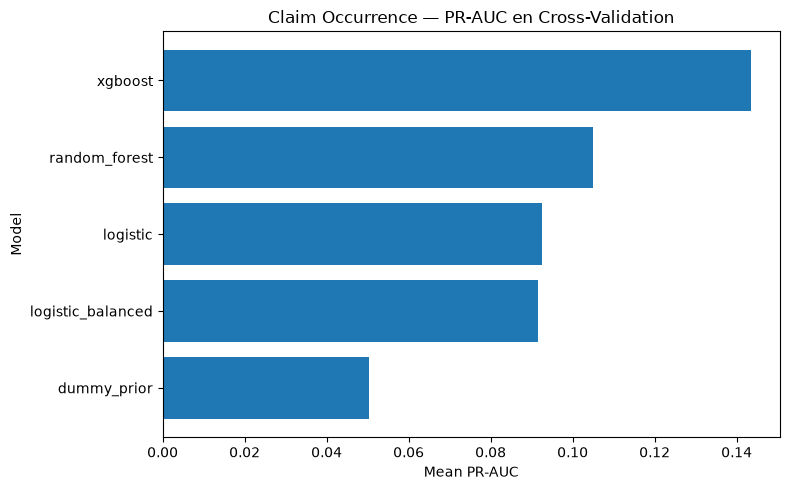

In [44]:
plot_data = (
    results_df
    .sort_values(
        "pr_auc_mean"
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data["model"],
    plot_data["pr_auc_mean"]
)

plt.xlabel(
    "Mean PR-AUC"
)

plt.ylabel(
    "Model"
)

plt.title(
    "Claim Occurrence — PR-AUC en Cross-Validation"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "claim_occurrence_pr_auc_comparison.png",
    dpi=150
)

plt.show()

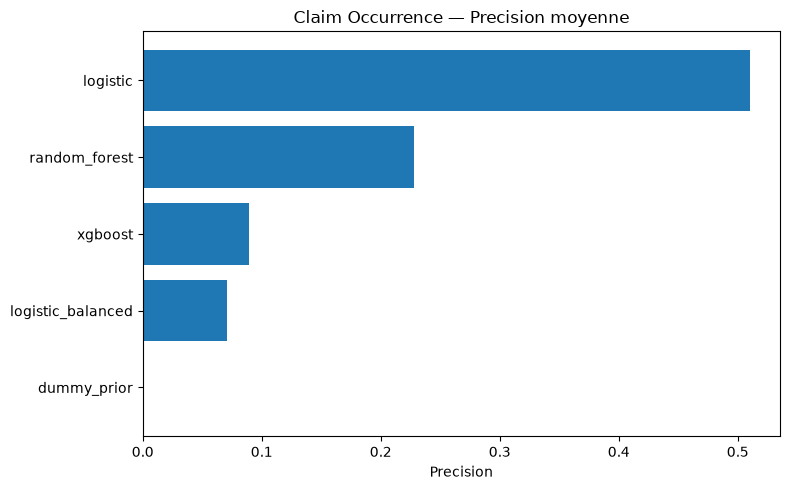

In [45]:
plot_data = (
    results_df
    .sort_values(
        "precision_mean"
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data["model"],
    plot_data["precision_mean"]
)

plt.xlabel(
    "Precision"
)

plt.title(
    "Claim Occurrence — Precision moyenne"
)

plt.tight_layout()

plt.show()

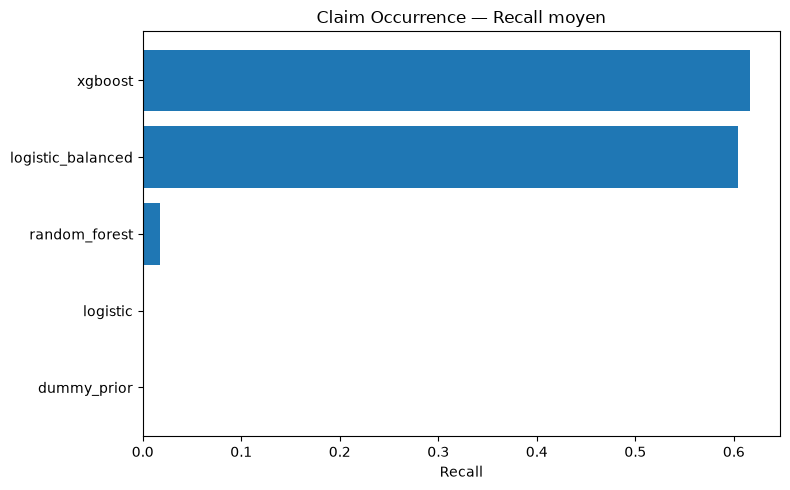

In [46]:
plot_data = (
    results_df
    .sort_values(
        "recall_mean"
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.barh(
    plot_data["model"],
    plot_data["recall_mean"]
)

plt.xlabel(
    "Recall"
)

plt.title(
    "Claim Occurrence — Recall moyen"
)

plt.tight_layout()

plt.show()

In [47]:
results_df[
    [
        "model",
        "pr_auc_mean"
    ]
].head()

,model,pr_auc_mean
0,xgboost,0.143401
1,random_forest,0.104955
2,logistic,0.092588
3,logistic_balanced,0.091644
4,dummy_prior,0.050250


In [48]:
oof_logistic_proba = cross_val_predict(
    estimator=logistic_pipeline,
    X=X_dev,
    y=y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

In [49]:
pd.Series(
    oof_logistic_proba
).describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
)

count    541431.000000
mean          0.050286
std           0.025900
min           0.000518
1%            0.015416
5%            0.020241
25%           0.031316
50%           0.045485
75%           0.063620
95%           0.095038
99%           0.134029
max           0.706002
dtype: float64

In [50]:
pd.Series(
    oof_logistic_proba
).describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99
    ]
)

count    541431.000000
mean          0.050286
std           0.025900
min           0.000518
1%            0.015416
5%            0.020241
25%           0.031316
50%           0.045485
75%           0.063620
95%           0.095038
99%           0.134029
max           0.706002
dtype: float64

In [51]:
assert (
    (oof_logistic_proba >= 0)
    &
    (oof_logistic_proba <= 1)
).all()

In [52]:
oof_pr_auc = average_precision_score(
    y_dev,
    oof_logistic_proba
)

print(
    "OOF PR-AUC :",
    oof_pr_auc
)

OOF PR-AUC : 0.09229195835173062


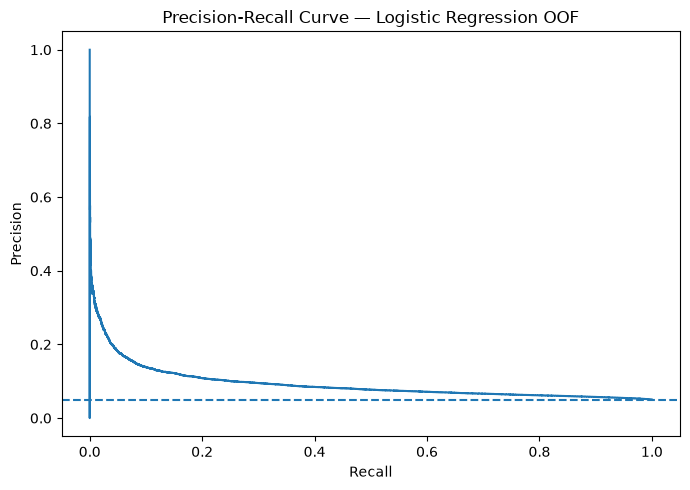

In [54]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_dev,
        oof_logistic_proba
    )
)
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    recall_values,
    precision_values
)

plt.axhline(
    y=positive_rate,
    linestyle="--"
)

plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Precision-Recall Curve — Logistic Regression OOF"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "logistic_oof_precision_recall_curve.png",
    dpi=150
)

plt.show()

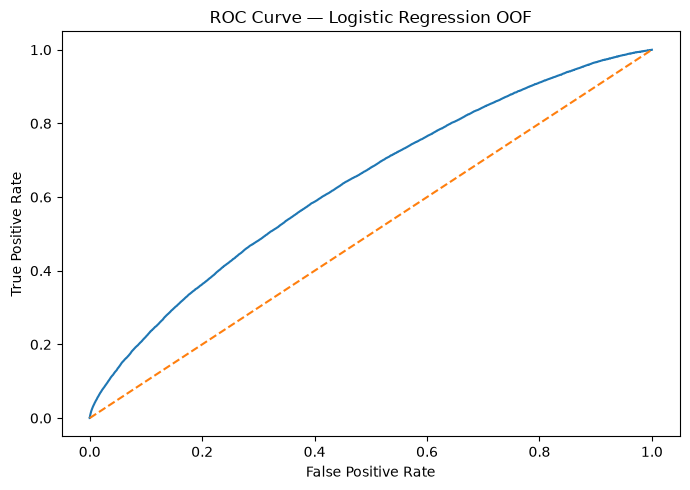

In [56]:
fpr, tpr, _ = roc_curve(
    y_dev,
    oof_logistic_proba
)

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    fpr,
    tpr
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Logistic Regression OOF"
)

plt.tight_layout()

plt.show()

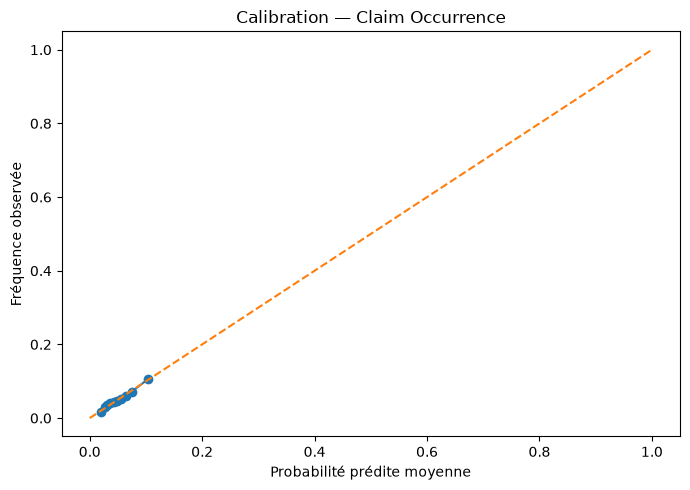

In [58]:
prob_true, prob_pred = calibration_curve(
    y_dev,
    oof_logistic_proba,
    n_bins=10,
    strategy="quantile"
)
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "Probabilité prédite moyenne"
)

plt.ylabel(
    "Fréquence observée"
)

plt.title(
    "Calibration — Claim Occurrence"
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "logistic_oof_calibration.png",
    dpi=150
)

plt.show()

In [59]:
oof_brier = brier_score_loss(
    y_dev,
    oof_logistic_proba
)

print(
    "OOF Brier Score :",
    oof_brier
)

OOF Brier Score : 0.04702471888426767


In [60]:
logistic_balanced_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, defau

In [61]:
oof_balanced_proba = cross_val_predict(
    estimator=logistic_balanced_pipeline,
    X=X_dev,
    y=y_dev,
    cv=cv,
    method="predict_proba",
    n_jobs=1
)[:, 1]

In [62]:
print(
    "PR-AUC logistic :",
    average_precision_score(
        y_dev,
        oof_logistic_proba
    )
)

print(
    "PR-AUC balanced :",
    average_precision_score(
        y_dev,
        oof_balanced_proba
    )
)

print()

print(
    "Brier logistic :",
    brier_score_loss(
        y_dev,
        oof_logistic_proba
    )
)

print(
    "Brier balanced :",
    brier_score_loss(
        y_dev,
        oof_balanced_proba
    )
)

PR-AUC logistic : 0.09229195835173062
PR-AUC balanced : 0.09134563741722489

Brier logistic : 0.04702471888426767
Brier balanced : 0.23501520579047377


In [63]:
oof_predictions = (
    occurrence_dev[
        [
            "IDpol",
            "has_claim"
        ]
    ]
    .copy()
)

oof_predictions[
    "logistic_probability"
] = oof_logistic_proba

oof_predictions[
    "logistic_balanced_probability"
] = oof_balanced_proba

In [64]:
oof_predictions.to_csv(
    REPORT_DIR
    / "claim_occurrence_oof_predictions.csv",
    index=False
)

# Analyse comparative des modèles — Claim Occurrence

La classe positive représente environ **5,025 %** des observations du jeu de développement.
Le problème est donc fortement déséquilibré.

La métrique principale retenue pour comparer les modèles est la **PR-AUC (Average Precision)**,
car elle est plus informative que l'accuracy dans ce contexte.

Les autres métriques permettent d'étudier :

- la discrimination globale avec ROC-AUC ;
- la détection des sinistres avec Recall ;
- la qualité des alertes avec Precision ;
- le compromis Precision/Recall avec F1 ;
- la qualité des probabilités avec le Brier Score ;
- la stabilité avec l'écart-type de PR-AUC entre folds ;
- le coût computationnel avec le temps d'entraînement.

---

## DummyClassifier

**PR-AUC : 0.0503**

**ROC-AUC : 0.5000**

**Brier Score : 0.0477**

**Recall : 0.0000**

**Precision : 0.0000**

### Interprétation

Le DummyClassifier constitue la baseline minimale du problème.

Sa PR-AUC de **0.0503** est pratiquement identique à la prévalence de la classe positive
(**5,025 %**), ce qui est attendu pour un modèle ne disposant d'aucun véritable pouvoir
prédictif.

Son ROC-AUC est de **0.50**, correspondant à une discrimination équivalente au hasard.

Au seuil de classification utilisé, le modèle ne détecte aucun contrat sinistré :

- Recall = 0 ;
- Precision = 0 ;
- F1 = 0.

Cette baseline montre donc que les modèles supervisés devront obtenir une PR-AUC
sensiblement supérieure à **0.0503** pour démontrer une réelle valeur prédictive.

---

## Logistic Regression

**PR-AUC moyenne : 0.0926**

**Écart-type PR-AUC : 0.0027**

**ROC-AUC : 0.6353**

**Recall : 0.0004**

**Precision : 0.5100**

**F1-score : 0.0007**

**Brier Score : 0.0470**

**Temps moyen d'entraînement : 4.07 secondes**

### Observation

La régression logistique améliore clairement la baseline :

- PR-AUC : **0.0926** contre **0.0503** pour Dummy ;
- ROC-AUC : **0.6353** contre **0.50** pour Dummy.

Le modèle contient donc réellement de l'information permettant de distinguer
les contrats présentant un sinistre des autres.

Cependant, avec le seuil par défaut de **0.5**, son Recall est pratiquement nul
(**0.0004**).

Cela signifie que le modèle prédit rarement une probabilité supérieure à 0.5,
ce qui est cohérent avec une classe positive très rare.

La Precision élevée (**0.5100** en moyenne CV, et environ **0.667** sur les prédictions OOF)
doit donc être interprétée avec prudence : très peu d'observations sont classées positives.

Le Brier Score de **0.0470** est le meilleur parmi les modèles testés et légèrement meilleur
que celui du DummyClassifier (**0.0477**).

La régression logistique non pondérée présente donc :

- une discrimination modérée ;
- un très mauvais Recall avec le seuil 0.5 ;
- mais des probabilités globalement bien calibrées par rapport aux modèles pondérés.

Le faible Recall ne signifie donc pas nécessairement que le modèle est inutile :
le seuil de 0.5 est probablement inadapté au problème et devra être étudié séparément.

---

## Logistic Regression Balanced

**PR-AUC moyenne : 0.0916**

**Écart-type PR-AUC : 0.0028**

**ROC-AUC : 0.6356**

**Recall : 0.6046**

**Precision : 0.0709**

**F1-score : 0.1270**

**Brier Score : 0.2350**

**Temps moyen d'entraînement : 4.23 secondes**

### Impact de `class_weight="balanced"`

L'utilisation de `class_weight="balanced"` modifie fortement le comportement
du modèle.

Par rapport à la régression logistique standard :

- PR-AUC passe de **0.0926** à **0.0916** ;
- ROC-AUC reste pratiquement identique ;
- Recall passe de presque **0 %** à environ **60.5 %** ;
- Precision chute fortement jusqu'à environ **7.1 %** ;
- F1 passe de **0.0007** à **0.1270**.

Sur les prédictions Out-of-Fold, l'impact mesuré est :

- Δ PR-AUC = **-0.000946** ;
- Δ Recall = **+0.604183** ;
- Δ Precision = **-0.595743** ;
- Δ F1 = **+0.126219**.

Le poids de classe ne permet donc pas réellement d'améliorer le pouvoir de classement
du modèle : PR-AUC et ROC-AUC restent presque identiques.

Il déplace surtout la frontière de décision afin de prédire beaucoup plus
d'observations comme positives.

Cela améliore fortement le Recall, mais au prix d'un grand nombre de faux positifs.

### Point important : calibration

Le Brier Score passe de :

**0.0470 → 0.2350**

soit une dégradation de **+0.188**.

Cette forte augmentation indique que les probabilités produites par le modèle équilibré
sont beaucoup moins bien calibrées.

`class_weight="balanced"` est donc intéressant pour étudier le compromis
Precision/Recall, mais il ne doit pas être interprété directement comme produisant
de meilleures probabilités de sinistre.

---

## Random Forest

**PR-AUC moyenne : 0.1050**

**Écart-type PR-AUC : 0.0013**

**ROC-AUC : 0.6668**

**Precision : 0.2278**

**Recall : 0.0178**

**F1-score : 0.0330**

**Brier Score : 0.0483**

**Temps moyen d'entraînement : 2208.4 secondes par fold**

### Performance

Random Forest améliore les performances de discrimination par rapport
aux régressions logistiques :

- PR-AUC = **0.1050** ;
- ROC-AUC = **0.6668**.

Cela suggère que certaines relations entre les variables et la cible sont probablement
non linéaires ou impliquent des interactions qu'une régression logistique simple
ne représente pas correctement.

Cependant, avec le seuil de 0.5, le Recall reste très faible :

**1.78 %**

Le modèle identifie donc très peu de sinistres avec ce seuil.

### Stabilité

L'écart-type de PR-AUC est seulement de :

**0.0013**

Il s'agit du plus faible écart-type parmi les vrais modèles testés.

Les performances sont donc relativement stables entre les folds.

### Coût computationnel

Le principal problème est le temps d'entraînement :

**≈ 2208 secondes par fold**, soit environ **36.8 minutes par fold**.

La validation croisée complète a nécessité plus de **3 heures**.

Ce coût est très élevé comparé à :

- Logistic Regression : ≈ 4 secondes/fold ;
- XGBoost : ≈ 20 secondes/fold.

Random Forest fournit donc une amélioration de PR-AUC,
mais avec un coût computationnel disproportionné dans la configuration actuelle.

---

## XGBoost

**PR-AUC moyenne : 0.1434**

**Écart-type PR-AUC : 0.0021**

**ROC-AUC : 0.7065**

**Precision : 0.0895**

**Recall : 0.6161**

**F1-score : 0.1562**

**Brier Score : 0.2041**

**Temps moyen d'entraînement : 20.03 secondes**

### Performance

XGBoost fournit les meilleures performances de discrimination parmi tous
les modèles testés.

La PR-AUC atteint :

**0.1434**

contre une baseline de seulement :

**0.0503**

La PR-AUC est donc près de trois fois supérieure à celle du DummyClassifier.

XGBoost obtient également le meilleur ROC-AUC :

**0.7065**

ce qui indique une meilleure capacité à classer les contrats sinistrés
au-dessus des contrats sans sinistre.

Au seuil par défaut :

- Recall = **0.6161** ;
- Precision = **0.0895** ;
- F1 = **0.1562**.

Il détecte donc environ **61.6 %** des observations positives,
mais avec une Precision encore faible en raison notamment du fort déséquilibre
du problème.

### Stabilité

L'écart-type de PR-AUC est :

**0.0021**

Cette valeur est faible relativement à la moyenne obtenue.

Les performances semblent donc relativement stables entre les cinq folds.

### Temps d'entraînement

Le temps moyen est d'environ :

**20 secondes par fold**.

XGBoost est donc beaucoup plus rapide que Random Forest dans la configuration testée,
tout en fournissant des performances nettement supérieures.

### Limitation importante : calibration

Le Brier Score est :

**0.2041**

ce qui est nettement moins bon que :

- Logistic Regression : **0.0470** ;
- DummyClassifier : **0.0477** ;
- Random Forest : **0.0483**.

Ce résultat doit être interprété avec prudence.

Le modèle utilise `scale_pos_weight` pour compenser le déséquilibre des classes.
Cette pondération améliore la détection de la classe minoritaire,
mais peut fortement modifier les probabilités produites.

XGBoost présente donc actuellement :

- la meilleure capacité de discrimination ;
- le meilleur PR-AUC ;
- le meilleur ROC-AUC ;
- un Recall élevé ;
- un coût computationnel raisonnable ;

mais ses probabilités ne peuvent pas encore être considérées comme
des probabilités de risque correctement calibrées.

Une étape de calibration sera nécessaire avant d'afficher directement
une valeur telle que :

`Probabilité de sinistre = 20 %`

dans l'application.

---

# Comparaison synthétique

| Modèle | PR-AUC | ROC-AUC | Precision | Recall | F1 | Brier | Temps/fold |
|---|---:|---:|---:|---:|---:|---:|---:|
| DummyClassifier | 0.0503 | 0.5000 | 0.0000 | 0.0000 | 0.0000 | 0.0477 | 2.98 s |
| Logistic Regression | 0.0926 | 0.6353 | 0.5100 | 0.0004 | 0.0007 | **0.0470** | 4.07 s |
| Logistic Balanced | 0.0916 | 0.6356 | 0.0709 | 0.6046 | 0.1270 | 0.2350 | 4.23 s |
| Random Forest | 0.1050 | 0.6668 | 0.2278 | 0.0178 | 0.0330 | 0.0483 | 2208.40 s |
| XGBoost | **0.1434** | **0.7065** | 0.0895 | **0.6161** | **0.1562** | 0.2041 | 20.03 s |

---

# Conclusion provisoire

Les expériences montrent d'abord que les variables disponibles contiennent
un signal prédictif réel.

Tous les modèles supervisés dépassent la baseline Dummy en termes de PR-AUC.

Les résultats mettent également en évidence une distinction importante entre :

1. **discrimination** ;
2. **classification à un seuil donné** ;
3. **calibration des probabilités**.

Un modèle peut être performant pour classer les observations sans pour autant
produire directement des probabilités correctement calibrées.

## Modèle principal retenu pour approfondissement

### 1. XGBoost

XGBoost est le candidat principal pour l'étape suivante car il obtient :

- la meilleure PR-AUC : **0.1434** ;
- le meilleur ROC-AUC : **0.7065** ;
- le meilleur Recall parmi les modèles testés au seuil actuel : **0.6161** ;
- le meilleur F1 : **0.1562** ;
- une faible variabilité entre folds : **± 0.0021** ;
- un temps d'entraînement raisonnable : environ **20 secondes par fold**.

Il fournit donc le meilleur compromis actuel en termes de discrimination,
détection de la classe positive et coût computationnel.

Cependant, son Brier Score élevé montre que ses probabilités devront être
recalibrées avant toute interprétation comme probabilités de sinistre.

---

## Deuxième candidat de référence

### 2. Logistic Regression

La régression logistique non pondérée est conservée comme deuxième candidat
et comme baseline statistique de référence.

Elle n'obtient pas la deuxième meilleure PR-AUC brute,
mais elle présente plusieurs avantages importants :

- entraînement très rapide ;
- modèle simple et interprétable ;
- stabilité correcte ;
- meilleur Brier Score : **0.0470** ;
- probabilités beaucoup plus proches de la prévalence observée.

Son Recall extrêmement faible au seuil de 0.5 ne suffit pas à l'éliminer,
car le seuil de décision n'a pas encore été optimisé.

Elle constitue donc un excellent modèle de comparaison pour étudier :

- l'effet du seuil ;
- la calibration ;
- le compromis complexité/performance ;
- l'intérêt réel d'un modèle non linéaire comme XGBoost.

---

## Situation de Random Forest

Random Forest obtient la deuxième meilleure PR-AUC brute :

**0.1050**

et présente une excellente stabilité :

**PR-AUC std = 0.0013**.

Cependant, son coût computationnel est extrêmement élevé :

**≈ 2208 secondes par fold**

pour une amélioration relativement modeste par rapport à la régression logistique.

Dans sa configuration actuelle, Random Forest n'est donc pas prioritaire pour
une recherche d'hyperparamètres intensive.

Il reste néanmoins un modèle de comparaison intéressant.

---

## Situation de Logistic Regression Balanced

La version équilibrée améliore fortement le Recall au seuil 0.5,
mais n'améliore ni PR-AUC ni ROC-AUC.

Elle dégrade également fortement la calibration :

**Brier : 0.0470 → 0.2350**

L'effet principal de `class_weight="balanced"` est donc de modifier
la frontière de décision et non d'améliorer réellement la capacité
de classement du modèle.

Cette configuration ne sera pas retenue comme modèle probabiliste final
dans son état actuel.

---

# Modèles retenus pour l'étape suivante

Les deux candidats principaux sont :

1. **XGBoost** — candidat principal pour la performance prédictive ;
2. **Logistic Regression** — baseline statistique interprétable et bien calibrée.

Random Forest reste un modèle secondaire de comparaison,
mais son coût computationnel actuel ne justifie pas une priorité de tuning.

---

# Étape suivante

La prochaine étape devra approfondir XGBoost et Logistic Regression sans utiliser
le jeu de test final.

Les travaux suivants seront notamment réalisés :

- tuning contrôlé des hyperparamètres de XGBoost ;
- comparaison avec la baseline logistique ;
- analyse détaillée des probabilités Out-of-Fold ;
- étude de la calibration ;
- comparaison avant/après calibration ;
- analyse de la courbe Precision-Recall ;
- étude du seuil de décision ;
- analyse de l'importance des variables ;
- SHAP pour le modèle arbre retenu.

Le jeu de test final reste fermé jusqu'à ce que le modèle,
ses hyperparamètres et la stratégie de calibration soient définitivement choisis.

# Conclusion — Claim Occurrence Model Comparison

Plusieurs familles de modèles ont été comparées sur exactement
les mêmes données de développement et les mêmes folds.

La comparaison inclut :

- une baseline naïve ;
- une régression logistique ;
- une régression logistique avec gestion du déséquilibre ;
- un Random Forest ;
- un Gradient Boosting via XGBoost.

La sélection n'est pas basée sur l'accuracy.

La métrique principale est PR-AUC, complétée par :

- ROC-AUC ;
- Precision ;
- Recall ;
- F1 ;
- Brier Score ;
- temps d'entraînement ;
- stabilité entre folds.

Les probabilités Out-of-Fold permettent également d'étudier
la calibration sans utiliser le jeu de test final.

Aucun modèle final n'est encore sauvegardé.

Le test set reste totalement fermé.

## Étape suivante

Les meilleurs candidats seront soumis à :

- tuning des hyperparamètres ;
- comparaison plus approfondie ;
- analyse de calibration ;
- choix éventuel du seuil ;
- évaluation finale sur le test set ;
- interprétabilité.